# Machine Learning 2025/2026

### Group no. 05 - David Silva no. 53755  / Luís Reis no. 64409 / Tiago Pereira no. 55854 

# ML Project  - Learning about Donations

## Task 0 - Exploratory Data Analysis

### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Loading Data

In [2]:
df_donors = pd.read_csv('Donors_dataset.csv')

In [3]:
# Data Set Visualization
df_donors.head()

,TARGET_B,TARGET_D,CONTROL_NUMBER,MONTHS_SINCE_ORIGIN,DONOR_AGE,IN_HOUSE,URBANICITY,SES,CLUSTER_CODE,HOME_OWNER,...,LIFETIME_GIFT_RANGE,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LAST_GIFT_AMT,CARD_PROM_12,NUMBER_PROM_12,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_FIRST_GIFT,FILE_AVG_GIFT,FILE_CARD_GIFT
0,0,NaN,5,101,87.0,0,?,?,.,H,...,15.0,20.0,5.0,15.0,5,12,26,92,8.49,7
1,1,10.0,12,137,79.0,0,R,2,45,H,...,20.0,25.0,5.0,17.0,7,21,7,122,14.72,12
2,0,NaN,37,113,75.0,0,S,1,11,H,...,23.0,28.0,5.0,19.0,11,32,6,105,16.75,16
3,0,NaN,38,92,NaN,0,U,2,4,H,...,14.0,17.0,3.0,15.0,11,33,6,92,11.76,12
4,0,NaN,41,101,74.0,0,R,2,49,U,...,20.0,25.0,5.0,25.0,6,19,18,92,8.83,3


In [4]:
# Data Structure Verification
print(f'df_donors')
print({df_donors.info()})

df_donors
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19372 entries, 0 to 19371
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TARGET_B                     19372 non-null  int64  
 1   TARGET_D                     4843 non-null   float64
 2   CONTROL_NUMBER               19372 non-null  int64  
 3   MONTHS_SINCE_ORIGIN          19372 non-null  int64  
 4   DONOR_AGE                    14577 non-null  float64
 5   IN_HOUSE                     19372 non-null  int64  
 6   URBANICITY                   19372 non-null  object 
 7   SES                          19372 non-null  object 
 8   CLUSTER_CODE                 19372 non-null  object 
 9   HOME_OWNER                   19372 non-null  object 
 10  DONOR_GENDER                 19372 non-null  object 
 11  INCOME_GROUP                 14980 non-null  float64
 12  PUBLISHED_PHONE              19372 non-null  int64  
 13  OVERLA

## 0.2. Understanding Data

In this task you should **understand better the features**, their distribution of values, potential errors, etc and plan/describe what data preprocessing steps should be performed next. Very important also is the distribution of values in the target (class distribution). 

Here you can find a notebook with some examples of what you can do in **Exploratory Data Analysis**: https://www.kaggle.com/artgor/exploration-of-data-step-by-step/notebook. You can also use Orange widgets for this.

In [10]:
# Missing Data Identification (Null Values Check)
missing_data = df_donors.isnull().sum()
print(missing_data[missing_data > 0])

TARGET_D                       14529
DONOR_AGE                       4795
INCOME_GROUP                    4392
WEALTH_RATING                   8810
MONTHS_SINCE_LAST_PROM_RESP      246
dtype: int64


In [8]:
# Selecting only numerical variables for correlation analysis
numerical_columns = df_donors.select_dtypes(include=['float64', 'int64']).columns

# Initialize a dictionary to hold the correlation values
correlation_dict = {}

# Calculate Pearson correlation for TARGET_D with each numerical variable
for column in numerical_columns:
    if column != 'TARGET_D' and column != 'TARGET_B':  # Skip the target variable and TARGET_B
        correlation = df_donors['TARGET_D'].corr(df_donors[column])
        correlation_dict[column] = correlation

# Convert the dictionary to a DataFrame for better visualization
correlation_table = pd.DataFrame(correlation_dict.items(), columns=['Variable', 'Pearson Coefficient'])

# Sort the DataFrame by 'Pearson Coefficient' in descending order
correlation_table_sorted = correlation_table.sort_values(by='Pearson Coefficient', ascending=False)

# Display the sorted correlation table
print(correlation_table_sorted.reset_index(drop=True))

                       Variable  Pearson Coefficient
0           RECENT_AVG_GIFT_AMT             0.707250
1                 LAST_GIFT_AMT             0.645388
2                 FILE_AVG_GIFT             0.516724
3         LIFETIME_AVG_GIFT_AMT             0.516724
4      RECENT_AVG_CARD_GIFT_AMT             0.477654
5         LIFETIME_MAX_GIFT_AMT             0.443145
6           LIFETIME_GIFT_RANGE             0.338629
7         LIFETIME_MIN_GIFT_AMT             0.295783
8          LIFETIME_GIFT_AMOUNT             0.247667
9             PER_CAPITA_INCOME             0.135409
10  MONTHS_SINCE_LAST_PROM_RESP             0.133834
11            MEDIAN_HOME_VALUE             0.126180
12                 INCOME_GROUP             0.126074
13      MEDIAN_HOUSEHOLD_INCOME             0.118255
14                WEALTH_RATING             0.114298
15       MONTHS_SINCE_LAST_GIFT             0.090215
16               NUMBER_PROM_12             0.064494
17                     IN_HOUSE             0.

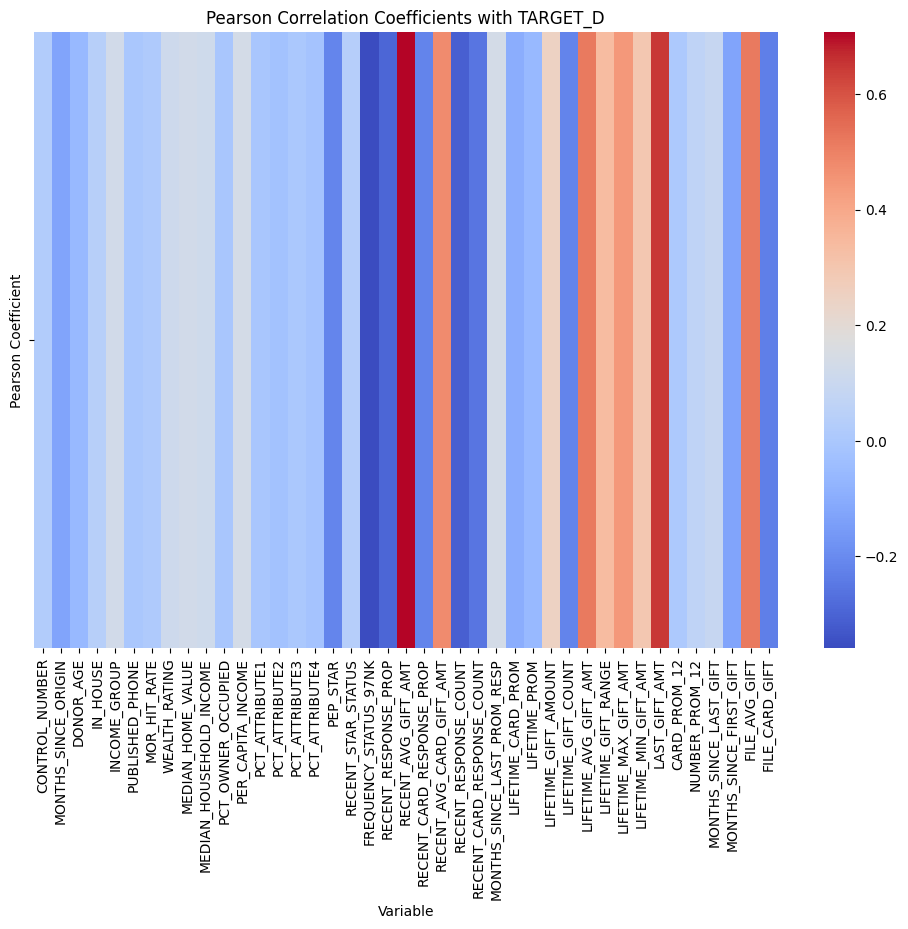

In [ ]:
# Heatmap Visualization of Correlation Coefficients
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_table.set_index('Variable').T, cmap='coolwarm', cbar=True, fmt=".2f")
plt.title('Pearson Correlation Coefficients with TARGET_D')
plt.show()

In [ ]:
# Strongly Positive Correlations (potential features for modeling)
#
#     RECENT_AVG_GIFT_AMT:         0.707250
#     LAST_GIFT_AMT:               0.645388
#     FILE_AVG_GIFT:               0.516724
#     LIFETIME_AVG_GIFT_AMT:       0.516724
#     RECENT_AVG_CARD_GIFT_AMT:    0.477654
#     LIFETIME_MAX_GIFT_AMT:       0.443145
#     LIFETIME_GIFT_RANGE:         0.338629
#     LIFETIME_MIN_GIFT_AMT:       0.295783
#     LIFETIME_GIFT_AMOUNT:        0.247667
#     PER_CAPITA_INCOME:           0.135409
#     MONTHS_SINCE_LAST_PROM_RESP: 0.133834
#     MEDIAN_HOME_VALUE:           0.126180
#     INCOME_GROUP:                 0.126074
#     MEDIAN_HOUSEHOLD_INCOME:      0.118255
#     WEALTH_RATING:                0.114298
#
# Strongly Negative Correlations (potential features for modeling)
#
#     FREQUENCY_STATUS_97NK:         -0.358655
#     RECENT_RESPONSE_COUNT:         -0.312299
#     RECENT_RESPONSE_PROP:          -0.292625
#     RECENT_CARD_RESPONSE_COUNT:    -0.256911
#     FILE_CARD_GIFT:                -0.229592
#     RECENT_CARD_RESPONSE_PROP:     -0.221056
#     LIFETIME_GIFT_COUNT:           -0.220247
#     PEP_STAR:                      -0.215399
#     MONTHS_SINCE_FIRST_GIFT:      -0.127522
#     MONTHS_SINCE_ORIGIN:           -0.126858
#     DONOR_AGE:                    -0.056139
#     LIFETIME_PROM:                -0.057903
#     LIFETIME_CARD_PROM:           -0.097675

In [11]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Identifying categorical variables
categorical_columns = df_donors.select_dtypes(include=['object']).columns

# Results for ANOVA
anova_results = {}

for column in categorical_columns:
    if column != 'TARGET_D':  # Ignoring the target variable
        # Fitting the ANOVA model
        model = ols(f'TARGET_D ~ C({column})', data=df_donors).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        # Storing results
        anova_results[column] = anova_table['PR(>F)'].iloc[0]  # P-value

# Converting results to DataFrame for better visualization
anova_results_df = pd.DataFrame(anova_results.items(), columns=['Variable', 'P-Value'])

# Displaying the results
print(anova_results_df)

              Variable       P-Value
0           URBANICITY  1.612702e-09
1                  SES  3.165017e-13
2         CLUSTER_CODE  3.142542e-08
3           HOME_OWNER  5.895921e-01
4         DONOR_GENDER  4.872228e-12
5       OVERLAY_SOURCE  2.945736e-01
6  RECENCY_STATUS_96NK  1.487957e-64


In [ ]:
# Interpretation of Results
#
# The printed DataFrame shows the categorical variables with their respective p-values:
#
#     URBANICITY: 1.612702e-09 — Significant.
#     SES: 3.165017e-13 — Highly significant.
#     CLUSTER_CODE: 3.142542e-08 — Significant.
#     HOME_OWNER: 5.895921e-01 — Not significant.
#     DONOR_GENDER: 4.872228e-12 — Highly significant.
#     OVERLAY_SOURCE: 2.945736e-01 — Not significant.
#     RECENCY_STATUS_96NK: 1.487957e-64 — Highly significant.
#
# Considerations
#
#     P-values < 0.05: Variables with very low p-values (such as URBANICITY, SES,
#     CLUSTER_CODE, DONOR_GENDER, and RECENCY_STATUS_96NK) are statistically significant
#     and may be included in the prediction model.
#     P-values > 0.05: Variables like HOME_OWNER and OVERLAY_SOURCE do not have a
#     significant association with TARGET_D and could be excluded in the context of the model.

...

## 0.3. Preprocessing Data

Here you might perform data preprocessing that will be used for both supervised and unsupervised learning tasks.

...

## Task 1 (Supervised Learning) - Predicting Donation and Donation Type

In this task you should target 2 classification tasks:
1. **Predicting Donation (binary classification task)** 
2. **Predicting Donation TYPE (multiclass classification)**

**You should:**

* Choose **5 classifiers** from **at least 3 of the following categories**: Tree models, Probabilistic models, Distance-based models and Linear models. You can also try one Ensemble Classifier (https://scikit-learn.org/1.5/modules/ensemble.html). 
* Use **cross-validation** to evaluate the results.
* Describe the parameters used for each classifier and how their choice impacted or not the results.
* Choose the **best classifier** and fundament you choice.
* Present and discuss the results for different evaluation measures, present confusion matrices. Remember that not only overall results are important. Check what happens when learning to predict each class. Remember also that some metrics might be more adequate than others according to the problem at hand.

* **Discuss critically your choices and the results!**

## 1.1. Specific Data Preprocessing for Classification

## 1.2. Learning and Evaluating Classifiers

...

The objective of this work was to develop a classification model using a Decision Tree to predict the probability of individuals becoming donors. The model was trained with 18 features that were selected both heuristically and numerically, incorporating a mix of numeric and categorical attributes. In this binary classification system, class 0 represents non-donors, while class 1 represents donors. The target variable is designated as target_B. This approach is aimed at enhancing the ability to identify potential donors effectively, which is crucial for various fundraising and donor engagement strategies.

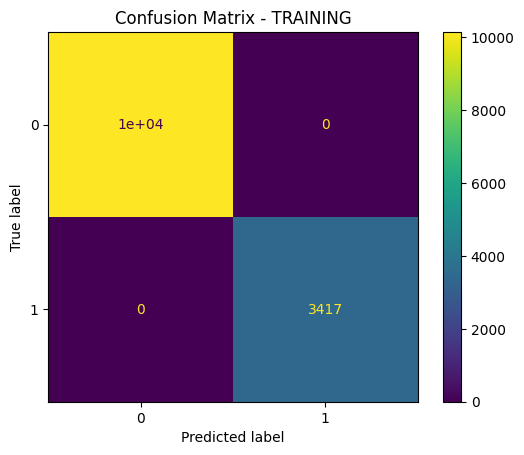

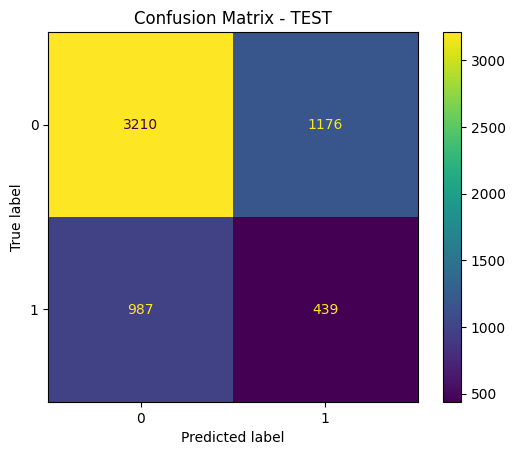

Confusion Matrix - TRAINING (list): [[10143, 0], [0, 3417]]
Confusion Matrix - TEST (list): [[3210, 1176], [987, 439]]

CLASSIFICATION - TRAINING:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10143
           1       1.00      1.00      1.00      3417

    accuracy                           1.00     13560
   macro avg       1.00      1.00      1.00     13560
weighted avg       1.00      1.00      1.00     13560

CLASSIFICATION - TEST:
              precision    recall  f1-score   support

           0       0.76      0.73      0.75      4386
           1       0.27      0.31      0.29      1426

    accuracy                           0.63      5812
   macro avg       0.52      0.52      0.52      5812
weighted avg       0.64      0.63      0.64      5812

F1 (class 1) - TRAIN: 1.0
F1 (class 1) - TEST : 0.28872081552121015


In [2]:
# Decision Tree Classifier for TARGET_B with 18 heuristically selected features

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT", 
    "LAST_GIFT_AMT", 
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", 
    "LIFETIME_MAX_GIFT_AMT", 
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", 
    "MONTHS_SINCE_FIRST_GIFT", 
    "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", 
    "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", 
    "RECENT_RESPONSE_COUNT", 
    "WEALTH_RATING"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keep only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)  # Predictions on the training set
y_test_pred = model.predict(X_test)     # Predictions on the test set

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=model.classes_)
disp_train.plot()
plt.title("Confusion Matrix - TRAINING")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=model.classes_)
disp_test.plot()
plt.title("Confusion Matrix - TEST")
plt.show()

# Display the confusion matrices as lists
print("Confusion Matrix - TRAINING (list):", train_matrix_list)
print("Confusion Matrix - TEST (list):", test_matrix_list)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICATION - TRAINING:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICATION - TEST:")
print(classification_report(y_test, y_test_pred))

print("F1 (class 1) - TRAIN:", f1_train)
print("F1 (class 1) - TEST :", f1_test)

The model achieved an accuracy of 100% on the training dataset, which is concerning and suggests that it has memorized the training data at the expense of generalizing to new data. The accuracy of 63% on the test dataset, along with the relatively low metrics for class 1, confirms that the model does not generalize well. This indicates a high number of false negatives and an inability to predict new donors. Although the decision tree model demonstrated excellent performance on the training data, the clear evidence of overfitting underscores the need for adjustments.

The next step involved training a Decision Tree model to predict the classification of the variable TARGET_B using nine features selected based on their correlation with the target variable. The numeric variables were chosen based on the values of the Pearson correlation coefficient, while the categorical variables were selected based on the ANOVA test. Among the selected numeric variables, the first five variables with the highest Pearson values were chosen. Notably, the variable FILE_AVG_GIFT and the variable LIFETIME_AVG_GIFT_AMT had the same value. Therefore, it is more appropriate to use only one of them; thus, the variable LIFETIME_AVG_GIFT_AMT was selected.

While all categorical variables with statistical significance based on the ANOVA test are potential candidates for inclusion, CLUSTER_CODE poses a unique challenge. Although it has a significant p-value, it encompasses a wide range of values, which can lead to high cardinality. The presence of many unique values results in additional categories. This complexity can foster overfitting, as the model may become overly focused on distinguishing between these potentially irrelevant distinctions without adding meaningful predictive power. Therefore, despite its statistical significance, the inclusion of CLUSTER_CODE may not be justified in the context of this model, and thus it was not included.

This approach aims to ensure that the selected features have a significant relationship with the target variable.

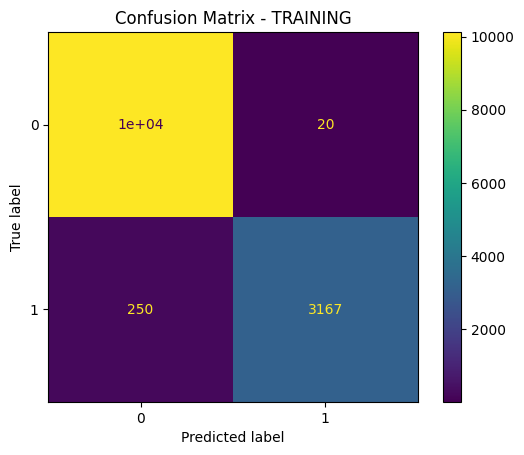

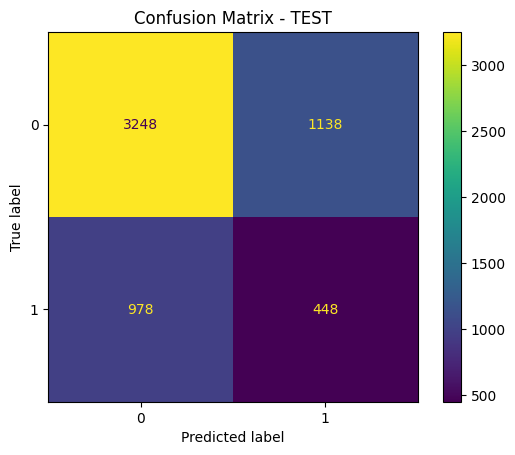

Confusion Matrix - TRAINING (list): [[10123, 20], [250, 3167]]
Confusion Matrix - TEST (list): [[3248, 1138], [978, 448]]

CLASSIFICATION - TRAINING:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     10143
           1       0.99      0.93      0.96      3417

    accuracy                           0.98     13560
   macro avg       0.98      0.96      0.97     13560
weighted avg       0.98      0.98      0.98     13560

CLASSIFICATION - TEST:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75      4386
           1       0.28      0.31      0.30      1426

    accuracy                           0.64      5812
   macro avg       0.53      0.53      0.53      5812
weighted avg       0.65      0.64      0.64      5812

F1 (class 1) - TRAIN: 0.9591156874621442
F1 (class 1) - TEST : 0.29747675962815406


In [3]:
# # Decision Tree Classifier for TARGET_B with 9 features selected based on correlation with pearson coefficient and ANOVA test

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keep only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)  # Predictions on the training set
y_test_pred = model.predict(X_test)     # Predictions on the test set

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=model.classes_)
disp_train.plot()
plt.title("Confusion Matrix - TRAINING")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=model.classes_)
disp_test.plot()
plt.title("Confusion Matrix - TEST")
plt.show()

# Display the confusion matrices as lists
print("Confusion Matrix - TRAINING (list):", train_matrix_list)
print("Confusion Matrix - TEST (list):", test_matrix_list)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICATION - TRAINING:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICATION - TEST:")
print(classification_report(y_test, y_test_pred))

print("F1 (class 1) - TRAIN:", f1_train)
print("F1 (class 1) - TEST :", f1_test)

The results demonstrate high performance during training, with an accuracy of 98% and excellent metrics for both classes. However, this performance in the testing phase is significantly lower, with an accuracy of only 64% and low precision and recall values for class 1 (donors). It can thus be concluded that, despite the feature selection being conducted based on sound reasoning, the results still indicate the presence of overfitting.

Upon examining the data, it is evident that there is a strong imbalance, with non-donor examples being approximately three times greater than donor examples. This issue can be addressed using the class balancing adjustment technique.

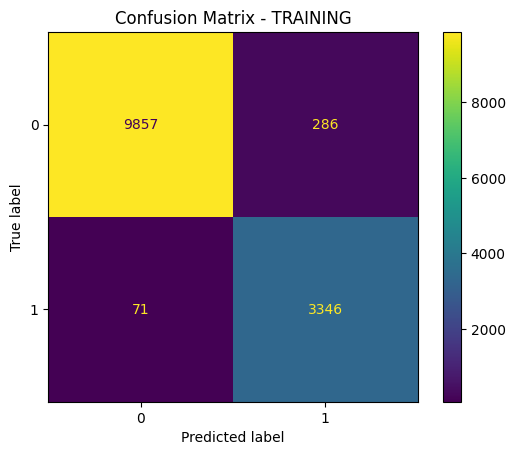

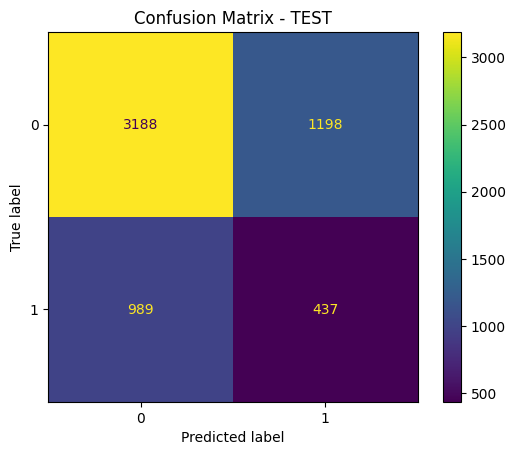

Confusion Matrix - TRAINING (list): [[9857, 286], [71, 3346]]
Confusion Matrix - TEST (list): [[3188, 1198], [989, 437]]

CLASSIFICATION - TRAINING:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     10143
           1       0.92      0.98      0.95      3417

    accuracy                           0.97     13560
   macro avg       0.96      0.98      0.97     13560
weighted avg       0.97      0.97      0.97     13560

CLASSIFICATION - TEST:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74      4386
           1       0.27      0.31      0.29      1426

    accuracy                           0.62      5812
   macro avg       0.52      0.52      0.52      5812
weighted avg       0.64      0.62      0.63      5812

F1 (class 1) - TRAIN: 0.9493545183714002
F1 (class 1) - TEST : 0.28552760535772626


In [5]:
# Decision Tree Classifier for TARGET_B with 9 features selected based on correlation with Pearson coefficient and ANOVA test
# Balanced weights for imbalanced classes

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keep only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Define the model with class weights
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Fit the model to the training data
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)  # Predictions on the training set
y_test_pred = model.predict(X_test)     # Predictions on the test set

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=model.classes_)
disp_train.plot()
plt.title("Confusion Matrix - TRAINING")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=model.classes_)
disp_test.plot()
plt.title("Confusion Matrix - TEST")
plt.show()

# Display the confusion matrices as lists
print("Confusion Matrix - TRAINING (list):", train_matrix_list)
print("Confusion Matrix - TEST (list):", test_matrix_list)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICATION - TRAINING:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICATION - TEST:")
print(classification_report(y_test, y_test_pred))

print("F1 (class 1) - TRAIN:", f1_train)
print("F1 (class 1) - TEST :", f1_test)

In the training results, the precision for class 0 slightly improved after balancing the class weights, while the precision for class 1 decreased marginally. However, recall for class 1 improved, indicating that the model is better at identifying actual 1s after adjusting for class imbalance. The F1 score for class 1 remains high but has slightly decreased, which indicates a trade-off between precision and recall.

In the testing results, both the precision and recall for class 0 slightly decreased. The precision for class 1 also saw a marginal decrease, while the recall values remained similar, showing consistency in the model’s predictive power for this class. The F1 score for class 1 decreased more noticeably after rebalancing, indicating that while balancing helps during training, it may not always enhance the model's generalization ability on unseen data.

While applying class weights improved the model's recall for the minority class (class 1), it had a minimal impact on overall performance, indicating a potential struggle with the balance in the test set. To maintain data representativeness, techniques such as SMOTE and ADASYN oversampling were applied, but the results were mediocre. Therefore, the next step involves performing hyperparameter tuning using the GridSearchCV technique. This approach aims to optimize the performance of the Decision Tree model by testing multiple combinations of hyperparameters.

Best parameters found: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


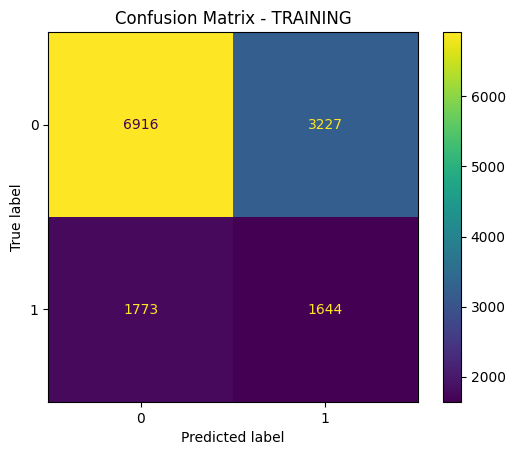

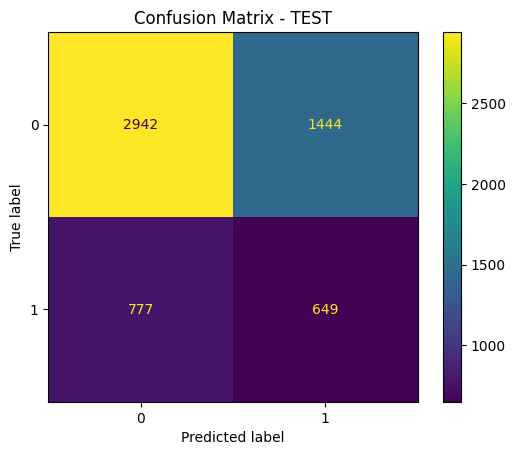

Confusion Matrix - TRAINING (list): [[6916, 3227], [1773, 1644]]
Confusion Matrix - TEST (list): [[2942, 1444], [777, 649]]

CLASSIFICATION - TRAINING:
              precision    recall  f1-score   support

           0       0.80      0.68      0.73     10143
           1       0.34      0.48      0.40      3417

    accuracy                           0.63     13560
   macro avg       0.57      0.58      0.57     13560
weighted avg       0.68      0.63      0.65     13560

CLASSIFICATION - TEST:
              precision    recall  f1-score   support

           0       0.79      0.67      0.73      4386
           1       0.31      0.46      0.37      1426

    accuracy                           0.62      5812
   macro avg       0.55      0.56      0.55      5812
weighted avg       0.67      0.62      0.64      5812

F1 (class 1) - TRAIN: 0.3967181467181467
F1 (class 1) - TEST : 0.3688547882921284


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keep only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best model from grid search
best_model = grid_search.best_estimator_

# Best parameters from GridSearch
print("Best parameters found:", grid_search.best_params_)

# Predictions using the best model
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=best_model.classes_)
disp_train.plot()
plt.title("Confusion Matrix - TRAINING")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=best_model.classes_)
disp_test.plot()
plt.title("Confusion Matrix - TEST")
plt.show()

# Display the confusion matrices as lists
print("Confusion Matrix - TRAINING (list):", train_matrix_list)
print("Confusion Matrix - TEST (list):", test_matrix_list)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICATION - TRAINING:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICATION - TEST:")
print(classification_report(y_test, y_test_pred))

print("F1 (class 1) - TRAIN:", f1_train)
print("F1 (class 1) - TEST :", f1_test)

In the training results, the precision for class 0 dropped significantly from 0.98 to 0.80, while precision for class 1 decreased sharply from 0.99 to 0.34. This indicates a substantial reduction in the model's ability to confidently identify the majority class and an even larger dip for the minority class. The F1 score for class 1 fell notably from 0.96 to 0.40, indicating that the model is less effective at balancing precision and recall after the application of GridSearchCV.

In the testing results, the precision for class 0 improved slightly, from 0.77 to 0.79, while the precision for class 1 saw a small increase as well (from 0.28 to 0.31). Recall for class 1 improved from 0.31 to 0.46, indicating better identification of the minority class. But F1 score for class 1 increased from 0.30 to 0.37, suggesting an improvement in the model's overall ability to identify true positives.

After applying GridSearchCV, the training results show a significant decline in performance. However, the testing results indicate some improvement in identifying class 1.

In an attempt to improve the results, stratified K-fold cross-validation was applied. The purpose of this technique is to enhance the model's generalization and prediction accuracy, especially in situations where the minority class is underrepresented. In this method, the dataset is divided into K groups (or "folds"), ensuring that the proportion between the classes (in this case, donors and non-donors) is maintained in each fold.

Best parameters found: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


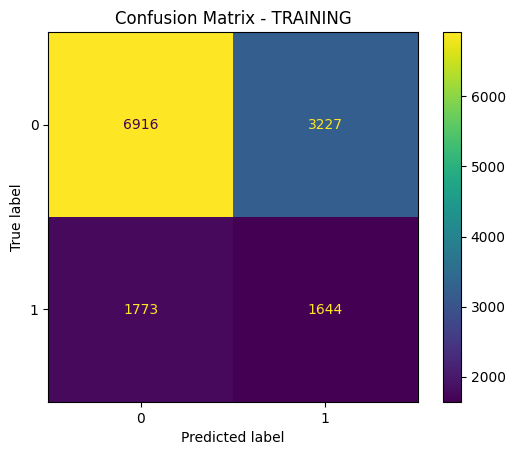

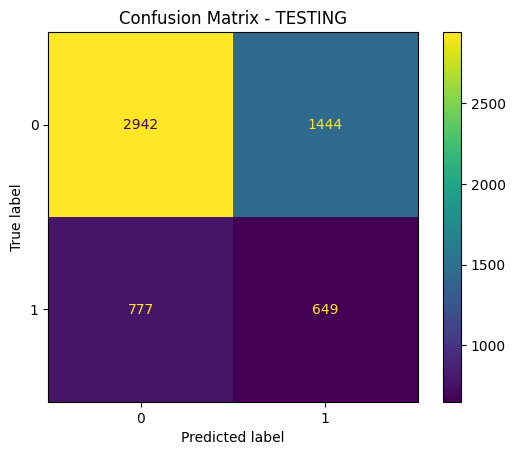

Confusion Matrix - TRAINING (list): [[6916, 3227], [1773, 1644]]
Confusion Matrix - TESTING (list): [[2942, 1444], [777, 649]]

CLASSIFICATION - TRAINING:
              precision    recall  f1-score   support

           0       0.80      0.68      0.73     10143
           1       0.34      0.48      0.40      3417

    accuracy                           0.63     13560
   macro avg       0.57      0.58      0.57     13560
weighted avg       0.68      0.63      0.65     13560

CLASSIFICATION - TESTING:
              precision    recall  f1-score   support

           0       0.79      0.67      0.73      4386
           1       0.31      0.46      0.37      1426

    accuracy                           0.62      5812
   macro avg       0.55      0.56      0.55      5812
weighted avg       0.67      0.62      0.64      5812

F1 (class 1) - TRAIN: 0.3967181467181467
F1 (class 1) - TEST : 0.3688547882921284


In [ ]:
# Decision Tree Classifier for TARGET_B with 9 features selected based on correlation with pearson coefficient and ANOVA test
# Balanced weights for imbalanced classes
# Hyperparameter tuning with GridSearchCV
# Applying Stratified K-Fold Cross-Validation


import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV with Stratified K-Fold
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=skf, scoring='f1', n_jobs=-1)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best model from grid search
best_model = grid_search.best_estimator_

# Best parameters from GridSearch
print("Best parameters found:", grid_search.best_params_)

# Predictions using the best model
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Confusion Matrix - Train
cm_train = confusion_matrix(y_train, y_train_pred)
train_matrix_list = cm_train.tolist()  # Convert to list for storage

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=best_model.classes_)
disp_train.plot()
plt.title("Confusion Matrix - TRAINING")
plt.show()

# Confusion Matrix - Test
cm_test = confusion_matrix(y_test, y_test_pred)
test_matrix_list = cm_test.tolist()  # Convert to list for storage

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=best_model.classes_)
disp_test.plot()
plt.title("Confusion Matrix - TESTING")
plt.show()

# Display the confusion matrices as lists
print("Confusion Matrix - TRAINING (list):", train_matrix_list)
print("Confusion Matrix - TESTING (list):", test_matrix_list)

# Evaluation metrics
# F1 Score for class 1 (donors)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("\nCLASSIFICATION - TRAINING:")
print(classification_report(y_train, y_train_pred))

print("CLASSIFICATION - TESTING:")
print(classification_report(y_test, y_test_pred))

print("F1 (class 1) - TRAIN:", f1_train)
print("F1 (class 1) - TEST :", f1_test)

The application of Stratified K-Fold Cross-Validation provided a more realistic assessment of the model's performance across different data splits. The similar F1 results for class 1 indicate that the model maintains a comparable ability to identify the minority class, even after applying cross-validation. This suggests that the model has a reasonable generalization and is not being drastically affected by the initial data selection or overfitting. 

Even with the consistency of the results, precision and recall, especially for class 1, still show challenges. This means that although the model is consistent, it can be improved to enhance the identification of the minority class.

Finally, the classification threshold was adjusted. This is a powerful technique for optimizing predictive models, allowing for fine-tuning of the model's outputs to meet the specific requirements of different applications. In this case, the classification threshold was adjusted based on the Precision-Recall curve to better balance precision and sensitivity (recall), with a focus on the donor class. In this context, identifying more positive cases, even if it increases the false positive rate, is crucial for the model's performance.

Optimal threshold: 0.41


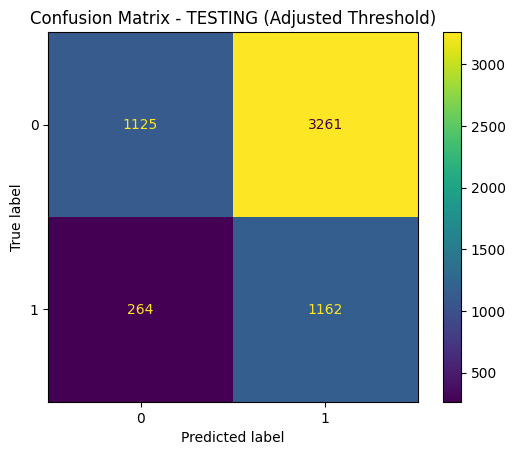

Confusion Matrix - TESTING (Adjusted Threshold) (list): [[1125, 3261], [264, 1162]]

Evaluation Metrics - Adjusted Threshold:
              precision    recall  f1-score   support

           0       0.81      0.26      0.39      4386
           1       0.26      0.81      0.40      1426

    accuracy                           0.39      5812
   macro avg       0.54      0.54      0.39      5812
weighted avg       0.68      0.39      0.39      5812

F1 Score (Adjusted Threshold): 0.3973


In [25]:
# Decision Tree Classifier for TARGET_B with 9 features selected based on correlation with pearson coefficient and ANOVA test (excluding CLUSTER_CODE)
# Balanced weights for imbalanced classes
# Hyperparameter tuning with GridSearchCV
# Applying Stratified K-Fold Cross-Validation
# Adjusting classification threshold based on Precision-Recall curve


import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

# Keeping only TARGET_B and selected predictors
df_B = df_cls[['TARGET_B'] + numeric_features + categorical_features].copy()

# Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_B[numeric_features] = num_imputer.fit_transform(df_B[numeric_features])
cat_imputer = SimpleImputer(strategy="most_frequent")
df_B[categorical_features] = cat_imputer.fit_transform(df_B[categorical_features])

# One-hot encoding for categorical variables
df_B_encoded = pd.get_dummies(df_B, columns=categorical_features, drop_first=True)

# Final X and y for the model
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV with Stratified K-Fold
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=skf, scoring='f1', n_jobs=-1)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_B_full, y_B_full, test_size=0.3, random_state=42)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best model from grid search
best_model = grid_search.best_estimator_

# Get predicted probabilities
y_probs = best_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Calculate F1 scores for each threshold
f1_scores = []
for p, r in zip(precision, recall):
    if (p + r) == 0:
        f1_scores.append(0.0)  # F1 score is zero if both precision and recall are zero
    else:
        f1_scores.append(2 * (p * r) / (p + r))

# Convert to a NumPy array for easier indexing
f1_scores = np.array(f1_scores)

# Determine the threshold with the best F1 score
best_index = np.argmax(f1_scores)
optimal_threshold = thresholds[best_index] if best_index < len(thresholds) else None

print(f"Optimal threshold: {optimal_threshold:.2f}")

# Make binary predictions based on the optimal threshold
y_test_pred_adjusted = (y_probs >= optimal_threshold).astype(int)

# Evaluation with the adjusted threshold
cm_test_adjusted = confusion_matrix(y_test, y_test_pred_adjusted)
test_matrix_adjusted_list = cm_test_adjusted.tolist()

disp_test_adjusted = ConfusionMatrixDisplay(confusion_matrix=cm_test_adjusted, display_labels=best_model.classes_)
disp_test_adjusted.plot()
plt.title("Confusion Matrix - TESTING (Adjusted Threshold)")
plt.show()

# Display the confusion matrix as a list
print("Confusion Matrix - TESTING (Adjusted Threshold) (list):", test_matrix_adjusted_list)

# Evaluation metrics for the adjusted threshold predictions
print("\nEvaluation Metrics - Adjusted Threshold:")
print(classification_report(y_test, y_test_pred_adjusted))

# F1 Score for class 1 (donors) with the adjusted threshold
f1_score_adjusted = f1_score(y_test, y_test_pred_adjusted, pos_label=1)
print(f"F1 Score (Adjusted Threshold): {f1_score_adjusted:.4f}")



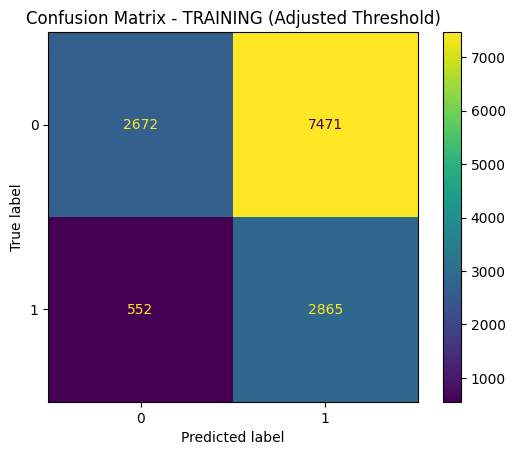

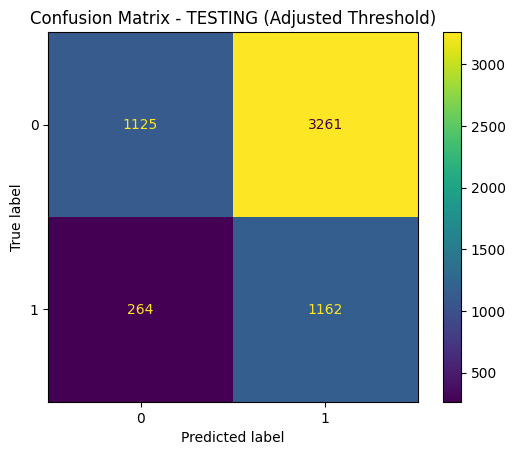

Confusion Matrix - TRAINING (Adjusted Threshold) (list): [[2672, 7471], [552, 2865]]
Confusion Matrix - TESTING (Adjusted Threshold) (list): [[1125, 3261], [264, 1162]]

Evaluation Metrics - TRAINING (Adjusted Threshold):
              precision    recall  f1-score   support

           0       0.83      0.26      0.40     10143
           1       0.28      0.84      0.42      3417

    accuracy                           0.41     13560
   macro avg       0.55      0.55      0.41     13560
weighted avg       0.69      0.41      0.40     13560

F1 Score (Adjusted Threshold - TRAINING): 0.4166

Evaluation Metrics - TESTING (Adjusted Threshold):
              precision    recall  f1-score   support

           0       0.81      0.26      0.39      4386
           1       0.26      0.81      0.40      1426

    accuracy                           0.39      5812
   macro avg       0.54      0.54      0.39      5812
weighted avg       0.68      0.39      0.39      5812

F1 Score (Adjusted Thre

In [26]:
# After calculating the optimal threshold and making predictions

# Make binary predictions for the training set using the optimal threshold
y_train_probs = best_model.predict_proba(X_train)[:, 1]
y_train_pred_adjusted = (y_train_probs >= optimal_threshold).astype(int)

# Confusion Matrix - Train with adjusted threshold
cm_train_adjusted = confusion_matrix(y_train, y_train_pred_adjusted)
train_matrix_adjusted_list = cm_train_adjusted.tolist()

disp_train_adjusted = ConfusionMatrixDisplay(confusion_matrix=cm_train_adjusted, display_labels=best_model.classes_)
disp_train_adjusted.plot()
plt.title("Confusion Matrix - TRAINING (Adjusted Threshold)")
plt.show()

# Confusion Matrix - Test with adjusted threshold
cm_test_adjusted = confusion_matrix(y_test, y_test_pred_adjusted)
test_matrix_adjusted_list = cm_test_adjusted.tolist()

disp_test_adjusted = ConfusionMatrixDisplay(confusion_matrix=cm_test_adjusted, display_labels=best_model.classes_)
disp_test_adjusted.plot()
plt.title("Confusion Matrix - TESTING (Adjusted Threshold)")
plt.show()

# Display confusion matrices as lists
print("Confusion Matrix - TRAINING (Adjusted Threshold) (list):", train_matrix_adjusted_list)
print("Confusion Matrix - TESTING (Adjusted Threshold) (list):", test_matrix_adjusted_list)

# Evaluation metrics for the adjusted threshold predictions for training set
print("\nEvaluation Metrics - TRAINING (Adjusted Threshold):")
print(classification_report(y_train, y_train_pred_adjusted))

# F1 Score for class 1 (donors) with the adjusted threshold
f1_score_train_adjusted = f1_score(y_train, y_train_pred_adjusted, pos_label=1)
print(f"F1 Score (Adjusted Threshold - TRAINING): {f1_score_train_adjusted:.4f}")

# Continue with previously shown test metrics evaluation
print("\nEvaluation Metrics - TESTING (Adjusted Threshold):")
print(classification_report(y_test, y_test_pred_adjusted))

# F1 Score for class 1 (donors) with the adjusted threshold
f1_score_test_adjusted = f1_score(y_test, y_test_pred_adjusted, pos_label=1)
print(f"F1 Score (Adjusted Threshold - TESTING): {f1_score_test_adjusted:.4f}")

Observing the results of true positives and false negatives, the model achieved a high recall. The recall for class 1 (donors) is relatively high (84% for training and 81% for testing). This indicates that the model is good at identifying donors, which is crucial since the objective is to ensure as many actual donors are identified as possible.

However, the number of false negatives is significant (552 in training and 264 in testing). This means that many actual donors are being missed, which is problematic for achieving the objective.

The precision for class 1 is low (28% for training and 26% for testing). This suggests that while the model identifies many true donors, a significant portion of its positive predictions are actually false positives. This indicates that the model often misclassifies non-donors as donors.

The F1 score (around 0.42 for training and 0.40 for testing) reflects the trade-off between precision and recall. Given the low precision and moderate recall, the model is not adequately balanced in its predictive abilities. This is not critical as the goal here is to maximize true positive identification of donors, even if it results in some false positives.

The overall accuracy is below 50% (41% for training and 39% for testing), suggesting that the model does not perform well on average. Accuracy can be misleading in imbalanced datasets, so it’s important to focus on the precision and recall metrics for the minority class, which is class 1 in this case.

In conclusion, the adjustment of the threshold led to an improvement in identifying class 1, although at the cost of precision, reflecting a trade-off often seen in classification problems with imbalanced classes. This results in a scenario where the model achieves a balance in the correctly identified examples between the classes: Class 1 (donors) has a high recall, indicating that many donors were correctly identified, but the low precision suggests the presence of many false positives; Class 0 (non-donors) performs better in precision, but it fails to correctly identify many of the non-donors.

## 1.3. Classification - Final Discussion and Conclusions 

...

## Task 2 (Unsupervised Learning) - Characterizing Donors and Donation Type

In this task you should **use unsupervised learning to characterize donors (people who really did a donation) and their donation type**.
1. **Use clustering algorithms to find similar groups of donors**. Is it possible to find groups of donors with the same/similar DonationTYPE? Evaluate clustering results using **internal and external metrics**.
2. **Be creative and define and explore your own clustering task!** What else would it be interesting to find out?

## 2.1. Preprocessing Data for Clustering

...

## 2.2. Learning and Evaluating Clusterings

...

## 2.3. Clustering - Final Discussion and Conclusions

...

## 3. Final Comments and Conclusions

...